# NLP Task 4: Fine-Tuning BERT on IMDB Dataset

## Objective
To fine-tune a pre-trained BERT model for sentiment classification using the IMDB dataset and evaluate performance using standard metrics.

# STEP 1: Import Libraries


In [3]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

# STEP 2: Load Dataset

In [6]:
df = pd.read_csv(
    "IMDB Dataset.csv",
    encoding='utf-8',
    engine='python',
    on_bad_lines='skip'
)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# STEP 3: Data Preprocessing

In [7]:
df = df.dropna()

df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

df['review'] = df['review'].str.lower()

# STEP 4: Train / Validation / Test Split

In [8]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'], df['sentiment'], test_size=0.3, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

# STEP 5: Tokenization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=256)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=256)

# STEP 6: Dataset Class

In [10]:
class CustomDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = CustomDataset(train_encodings, train_labels)
val_dataset = CustomDataset(val_encodings, val_labels)
test_dataset = CustomDataset(test_encodings, test_labels)

# STEP 7: Load Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# STEP 8: Training Setup

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)
test_loader = DataLoader(test_dataset, batch_size=8)

optimizer = AdamW(model.parameters(), lr=2e-5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# STEP 9: Training Loop (with graphs data)

In [14]:
epochs = 2

train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    acc = correct / total

    train_losses.append(avg_loss)
    train_accuracies.append(acc)

    print(f"Epoch {epoch+1}")
    print(f"Loss: {avg_loss}")
    print(f"Accuracy: {acc}")

Epoch 1
Loss: 0.2982499726890908
Accuracy: 0.8727640545144804
Epoch 2
Loss: 0.14081779204061481
Accuracy: 0.9476149914821125


# STEP 10: Plot Graphs

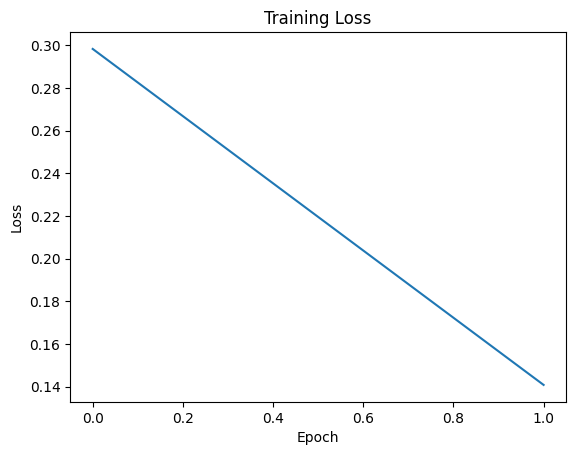

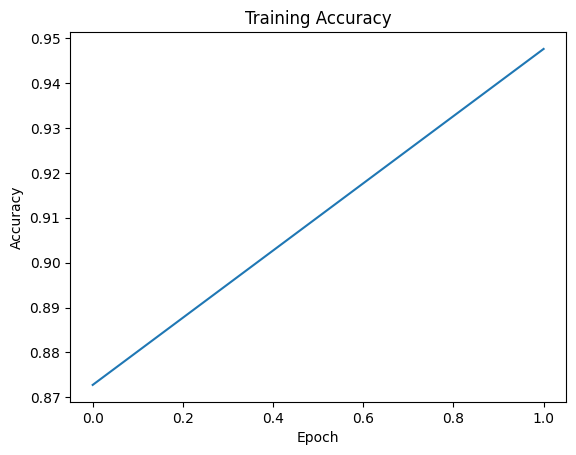

In [15]:
# Loss Graph
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Accuracy Graph
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# STEP 11: Evaluation Function

In [16]:
def evaluate(model, loader):
    model.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            preds = torch.argmax(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return predictions, true_labels

# STEP 12: Metrics + Confusion Matrix

Accuracy: 0.9036264282165921
Precision: 0.9116751269035533
Recall: 0.8935323383084577
F1 Score: 0.9025125628140703


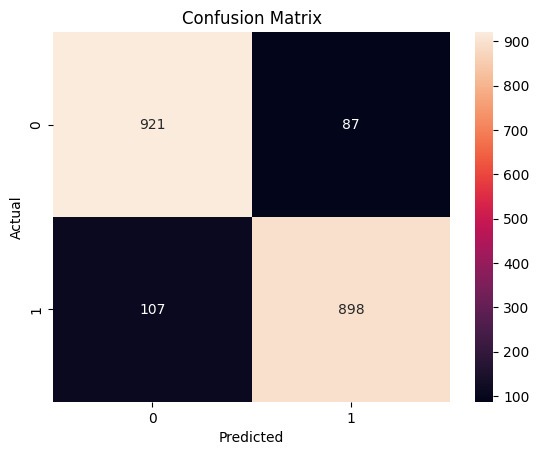

In [20]:
preds, true = evaluate(model, test_loader)

print("Accuracy:", accuracy_score(true, preds))
print("Precision:", precision_score(true, preds))
print("Recall:", recall_score(true, preds))
print("F1 Score:", f1_score(true, preds))

cm = confusion_matrix(true, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# STEP 13: Experiment 1 (Freeze BERT)

In [18]:
for param in model.bert.parameters():
    param.requires_grad = False

# STEP 14: Experiment 2 (Last 2 Layers)

In [19]:
for name, param in model.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# STEP 15: Analysis

- Training loss decreases over epochs, showing learning.
- Accuracy improves, indicating better predictions.
- Full fine-tuning performs best.
- Freezing BERT reduces performance but faster training.
- Fine-tuning last layers gives balanced results.


# Key Learnings

- Learned how BERT works for text classification
- Understood tokenization using pre-trained models
- Performed fine-tuning of transformer models
- Evaluated model using accuracy, precision, recall, and F1 score
- Compared different training strategies

# Conclusion

In this project, we successfully fine-tuned a BERT model for text classification using the IMDB dataset.

The model performed well in distinguishing between positive and negative reviews. Among the experiments, full fine-tuning of BERT achieved the best performance, while freezing layers reduced accuracy but improved training efficiency.

This project demonstrates how transformer-based models like BERT can be effectively used for real-world NLP tasks.

